In [ ]:
import torch
import math
import numpy as np

from StochasticVolatilityModel import StochasticVolatilityModel
from ValueNetwork import ValueNetwork
from lnSRE_Equation import lnSRE_Equation
from DBDPLnSRESolver import DBDPLnSRESolver

In [5]:
import numpy as np

#Market parameter from 2015-2019 for ETFs (a: XLK, b: XLF, c: XLE, d: XLV, M: S&P 500)

learned_params={'r': 0.02,
 'alpha_M': np.float64(0.31758716229363354),
 'beta_M': np.float64(12.865293073450562),
 'sigma_M': np.float64(0.5567144599143198),
 'V_M_0': np.float64(0.0189888392640686),

 'm_WM': np.float64(3.354523485100627),
 'rho_M_own': np.float64(-0.7642250277122952),
 'alpha_a': np.float64(0.07727275369083576),
 'beta_a': np.float64(6.487735427328434),
 'sigma_a': np.float64(0.23066160515955714),
 'V_a_0': np.float64(0.0012848933407741759),
 'gamma_aM': np.float64(0.10409094494463005),
 'delta_a': np.float64(1.2913818216054989),
 'rho_a_own': np.float64(-0.14001667734830328),
 'rho_aM': np.float64(-0.23725634573966328),
 'm_Wa': np.float64(9.431835928740613),
 'm_W_a': np.float64(9.431835928740613),

 'alpha_b': np.float64(0.12318490140550321),
 'beta_b': np.float64(5.403004898619638),
 'sigma_b': np.float64(0.3138066810004761),
 'V_b_0': np.float64(0.005771490909311954),
 'gamma_bM': np.float64(0.1295705460845422),
 'delta_b': np.float64(1.3909018688410821),
 'rho_b_own': np.float64(0.13820211398549068),
 'rho_bM': np.float64(-0.18857046827588872),
 'm_Wb': np.float64(1.3015027352197628),
 'm_W_b': np.float64(1.3015027352197628),

 'alpha_c': np.float64(0.3131507669534341),
 'beta_c': np.float64(4.518314982255215),
 'sigma_c': np.float64(0.4862757188147902),
 'V_c_0': np.float64(0.021239945146650497),
 'gamma_cM': np.float64(0.11340752901865712),
 'delta_c': np.float64(1.5260306838894788),
 'rho_c_own': np.float64(0.1459288721760854),
 'rho_cM': np.float64(-0.09135745509553944),
 'm_Wc': np.float64(-1.687284055716071),
 'm_W_c': np.float64(-1.687284055716071),

 'alpha_d': np.float64(0.06143494062158897),
 'beta_d': np.float64(4.301198282673263),
 'sigma_d': np.float64(0.23794924421903255),
 'V_d_0': np.float64(0.0022944511885847176),
 'gamma_dM': np.float64(0.094963395374469),
 'delta_d': np.float64(1.0238773268690975),
 'rho_d_own': np.float64(-0.17585205340095938),
 'rho_dM': np.float64(-0.17265007426401133),
 'm_Wd': np.float64(2.4033245803872934),
 'm_W_d': np.float64(2.4033245803872934)}

In [6]:
import torch
import math

T_HORIZON = 1.0
N_SIMS = 16
DT = 1/252
N_STEPS = int(T_HORIZON / DT)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'



In [7]:
simulator = StochasticVolatilityModel(learned_params)

value_net = ValueNetwork(
    num_steps=int(T_HORIZON / DT),
    state_dim=5,
    hidden_layers=[64,64]
).to(DEVICE)

sre_eq = lnSRE_Equation(learned_params, device=DEVICE)

solver = DBDPLnSRESolver(
    params=learned_params,
    value_net=value_net,
    sre_equation=sre_eq,
    dt=DT,
    T=T_HORIZON,
    device=DEVICE
)


    -> N_steps: 252


In [8]:
import torch
import numpy as np
import time
import math
import matplotlib.pyplot as plt

class OutOfSampleEvaluator:
    def __init__(self, solver, simulator, device='cpu'):
        self.solver = solver
        self.simulator = simulator
        self.device = device

    def generate_out_of_sample_history(self, model_path, num_scenarios=20000, seed=9999):
        print(f"\n[Evaluator] Loading from {model_path} ...")

        checkpoint = torch.load(model_path, map_location=self.device, weights_only=False)
        self.solver.value_net.load_state_dict(checkpoint['value_net_state'])
        self.solver.P0.data = torch.tensor([checkpoint.get('P0', 0.0)], dtype=torch.float64, device=self.device)
        if 'Lambda_active_0' in checkpoint:
            self.solver.Lambda_active_0.data = checkpoint['Lambda_active_0'].to(self.device)

        self.solver.value_net.eval()

        check_p0_value = self.solver.P0.item()

        print(f"[Evaluator] Generating {num_scenarios:,} physical tensors (Seed: {seed})...")
        t0 = time.time()
        V_test, dW_test = self.simulator.simulate_tensors(
            num_days=self.solver.N_steps,
            dt=self.solver.dt,
            num_scenarios=num_scenarios,
            seed=seed
        )
        t1 = time.time()
        print(f"[Evaluator] Tensors generated in {t1 - t0:.2f} seconds.")

        print("[Evaluator] Running gradient-free forward log BSDE evolution...")
        check_P_history = np.zeros((num_scenarios, self.solver.N_steps + 1))
        check_P_history[:, 0] = check_p0_value
        batch_size = num_scenarios
        check_P_t = torch.full((batch_size, 1), check_p0_value, dtype=torch.float64, device=self.device)

        t2 = time.time()
        with torch.no_grad():
            check_Lambda_t = self.solver.Lambda0.expand(batch_size, -1)

            for i in range(self.solver.N_steps):
                t_curr = (i * self.solver.dt) / self.solver.T
                V_curr = V_test[:, i, :]
                dW_curr = dW_test[:, i, :]

                drift = self.solver.sre_equation(t_curr, check_P_t, check_Lambda_t, V_curr)
                diffusion_term = torch.sum(check_Lambda_t * dW_curr, dim=1, keepdim=True)

                check_P_t = check_P_t + drift * self.solver.dt + diffusion_term

                check_P_history[:, i + 1] = check_P_t.cpu().numpy().flatten()

                if i + 1 < self.solver.N_steps:
                    V_next = V_test[:, i + 1, :].clone().detach().requires_grad_(True)
                    with torch.enable_grad():
                        check_P_next = self.solver.value_net(i + 1, V_next)
                        grad_check_P = torch.autograd.grad(
                            outputs=check_P_next,
                            inputs=V_next,
                            grad_outputs=torch.ones_like(check_P_next),
                            create_graph=False,
                            retain_graph=False,
                            only_inputs=True
                        )[0]
                    Lambda_active = (grad_check_P * self.solver.sigma_V_tensor * torch.sqrt(torch.clamp(V_next, min=1e-8))).detach()
                    pad_zeros = torch.zeros(batch_size, 9, dtype=torch.float64, device=self.device)
                    check_Lambda_t = torch.cat([Lambda_active, pad_zeros], dim=1)

        t3 = time.time()
        print(f"[Evaluator] Evolution completed for {batch_size:,} paths in {t3 - t2:.2f} seconds.")

        return check_P_history, check_p0_value

    def evaluate_statistics(self, check_P_history, check_p0_value, seed=9999):
        num_scenarios = check_P_history.shape[0]
        check_P_T_pred = check_P_history[:, -1]

        mean_yt = np.mean(check_P_T_pred)
        std_yt = np.std(check_P_T_pred)

        mse_loss = np.mean((check_P_T_pred - 0.0) ** 2)
        max_dev = np.max(np.abs(check_P_T_pred - 0.0))

        percentile_99 = np.percentile(check_P_T_pred, 99)
        percentile_01 = np.percentile(check_P_T_pred, 1)

        print("\n" + "="*75)
        print(" [ DBDP2 Out-of-Sample Report ] ")
        print("="*75)
        print(f" Test Paths         : {num_scenarios:,}")
        print(f" Random Seed        : {seed}")
        print("-" * 75)
        print(f" check_P(0)         : {check_p0_value:.6f}  (Exp P(0): {math.exp(check_p0_value):.6f})")
        print(f" Terminal Mean      : {mean_yt:.6f}  (Target: 0.000000)")
        print(f" Terminal Std       : {std_yt:.6f}")
        print(f" MSE                : {mse_loss:.2e}")
        print("-" * 75)
        print(" [ Tail Risk Diagnostics (Target: 0.0) ] ")
        print(f" Max Abs Deviation  : {max_dev:.4f}")
        print(f" 99th Percentile    : {percentile_99:.4f}")
        print(f" 1st Percentile     : {percentile_01:.4f}")
        print("="*75)

        return mean_yt, std_yt, mse_loss

    def plot_path_distribution(self, check_P_history):
        num_scenarios = check_P_history.shape[0]
        print(f"\n[Visualizer] Plotting funnel distribution for {num_scenarios:,} paths...")

        time_steps = np.linspace(0, self.solver.T, self.solver.N_steps + 1)

        p_mean = np.mean(check_P_history, axis=0)
        p_min = np.min(check_P_history, axis=0)
        p_max = np.max(check_P_history, axis=0)
        p_01 = np.percentile(check_P_history, 1, axis=0)
        p_99 = np.percentile(check_P_history, 99, axis=0)
        p_10 = np.percentile(check_P_history, 10, axis=0)
        p_90 = np.percentile(check_P_history, 90, axis=0)

        fig, ax = plt.subplots(figsize=(12, 7), dpi=150)

        ax.fill_between(time_steps, p_min, p_max, color='#1f77b4', alpha=0.08, label='Absolute Range (Min-Max)')
        ax.fill_between(time_steps, p_01, p_99, color='#1f77b4', alpha=0.20, label='98% Interval (1st-99th Pct)')
        ax.fill_between(time_steps, p_10, p_90, color='#1f77b4', alpha=0.35, label='80% Interval (10th-90th Pct)')

        ax.plot(time_steps, p_mean, color='#d62728', linewidth=2.5, label=r'Empirical Mean $\mathbb{E}[\check{P}_t]$')
        ax.axhline(y=0.0, color='#2ca02c', linestyle='--', linewidth=2, label=r'Theoretical Target ($\check{P}_T = 0.0$)')

        ax.set_title(rf'Log-Space Distribution Evolution of $\check{{P}}(t)$ ({num_scenarios:,} Scenarios)', fontsize=15, pad=15, fontweight='bold')
        ax.set_xlabel('Time $t$', fontsize=13)
        ax.set_ylabel(r'Log State Value $\check{P}(t)$', fontsize=13)
        ax.tick_params(axis='both', which='major', labelsize=11)
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend(loc='lower right', fontsize=11, framealpha=0.95)

        plt.tight_layout()
        plt.show()

    def plot_sample_paths(self, check_P_history, num_plot_paths=200):
        n_paths = min(num_plot_paths, check_P_history.shape[0])
        print(f"\n[Visualizer] Plotting {n_paths} sampled trajectories...")

        P_sub = check_P_history[:n_paths, :]
        time_steps = np.linspace(0, self.solver.T, self.solver.N_steps + 1)

        fig, ax = plt.subplots(figsize=(12, 7), dpi=150)

        ax.plot(time_steps, P_sub.T, color='#1f77b4', alpha=0.05, linewidth=0.8)

        mean_path = np.mean(P_sub, axis=0)
        ax.plot(time_steps, mean_path, color='#d62728', linewidth=2.5, label=r'Empirical Mean Path $\mathbb{E}[\check{P}_t]$')

        ax.axhline(y=0.0, color='#2ca02c', linestyle='--', linewidth=2, label=r'Theoretical Target ($\check{P}_T = 0.0$)')

        ax.set_title(rf'Trajectories of $\check{{P}}(t)$ (Sampled {n_paths} Scenarios)', fontsize=15, pad=15, fontweight='bold')
        ax.set_xlabel('Time $t$', fontsize=13)
        ax.set_ylabel(r'Log State Value $\check{P}(t)$', fontsize=13)
        ax.tick_params(axis='both', which='major', labelsize=11)
        ax.grid(True, linestyle=':', alpha=0.6)

        ax.plot([], [], color='#1f77b4', alpha=0.6, linewidth=2, label='Simulated Trajectories')
        ax.legend(loc='best', fontsize=12, framealpha=0.9)

        plt.tight_layout()
        plt.show()


[Evaluator] Loading from value_net_final_complete_set2.pt ...
[Evaluator] Generating 50,000 physical tensors (Seed: 9999)...
[Evaluator] Tensors generated in 0.40 seconds.
[Evaluator] Running gradient-free forward log BSDE evolution...


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


[Evaluator] Evolution completed for 50,000 paths in 8.13 seconds.

 [ DBDP2 Out-of-Sample Report ] 
 Test Paths         : 50,000
 Random Seed        : 9999
---------------------------------------------------------------------------
 check_P(0)         : -1.273976  (Exp P(0): 0.279717)
 Terminal Mean      : 0.000314  (Target: 0.000000)
 Terminal Std       : 0.032782
 MSE                : 1.07e-03
---------------------------------------------------------------------------
 [ Tail Risk Diagnostics (Target: 0.0) ] 
 Max Abs Deviation  : 0.3652
 99th Percentile    : 0.1063
 1st Percentile     : -0.0519

[Visualizer] Plotting funnel distribution for 50,000 paths...


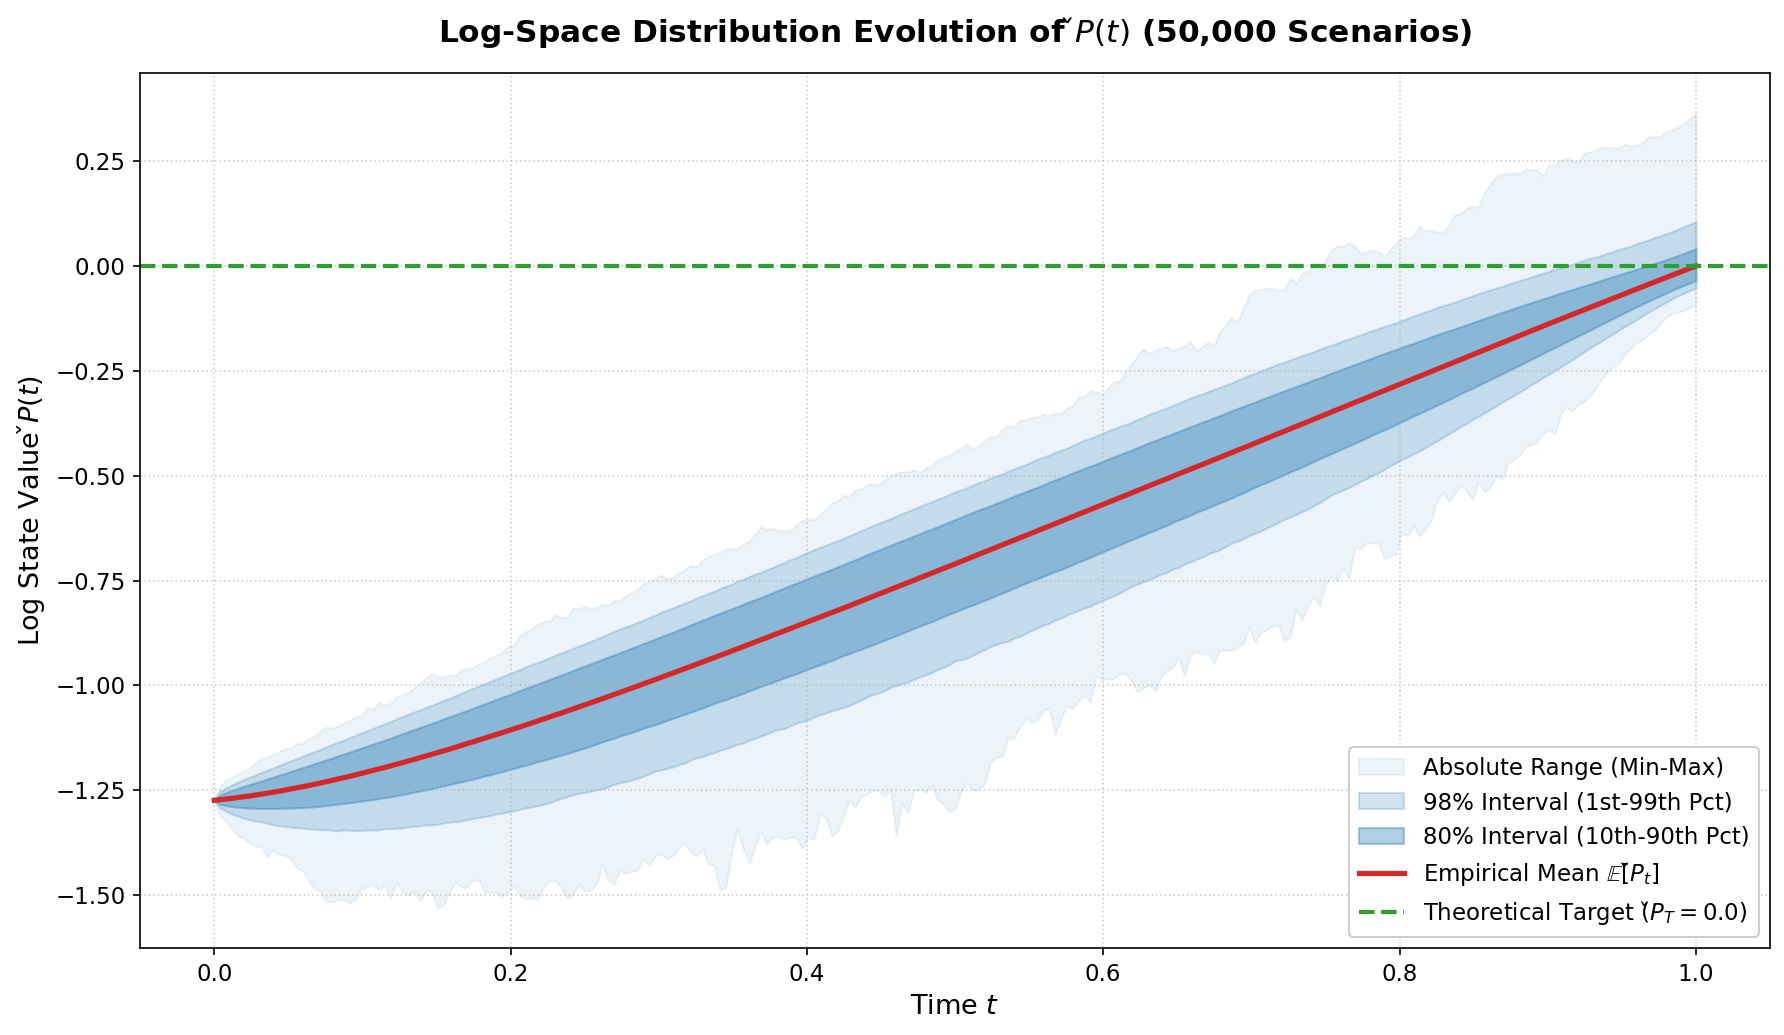

In [9]:

evaluator = OutOfSampleEvaluator(
    solver=solver,
    simulator=simulator,
    device=DEVICE
)

MODEL_PATH = 'value_net_final_complete_set2.pt'
TEST_SEED = 9999
TEST_SCENARIOS = 50000


check_P_history_oos, check_p0_val = evaluator.generate_out_of_sample_history(
    model_path=MODEL_PATH,
    num_scenarios=TEST_SCENARIOS,
    seed=TEST_SEED
)

mean_yt, std_yt, mse_loss = evaluator.evaluate_statistics(
    check_P_history=check_P_history_oos,
    check_p0_value=check_p0_val,
    seed=TEST_SEED
)


evaluator.plot_path_distribution(
    check_P_history=check_P_history_oos
)

In [10]:
import torch
import numpy as np
import time
import math
import matplotlib.pyplot as plt

class TrueSREVerifier_OriginalScale:
    def __init__(self, solver, device='cpu'):
        self.solver = solver
        self.device = device

    def generate_true_sre_history(self, model_path, V_test, dW_test):
        print(f"\n[True SRE Verifier] Loading from {model_path}...")

        checkpoint = torch.load(model_path, map_location=self.device, weights_only=False)
        self.solver.value_net.load_state_dict(checkpoint['value_net_state'])
        self.solver.P0.data = torch.tensor([checkpoint.get('P0', 0.0)], dtype=torch.float64, device=self.device)
        if 'Lambda_active_0' in checkpoint:
            self.solver.Lambda_active_0.data = checkpoint['Lambda_active_0'].to(self.device)

        self.solver.value_net.eval()

        check_p0_value = self.solver.P0.item()
        p0_true = math.exp(check_p0_value)

        print("[True SRE Verifier] Log-protection removed. Physical scale active.")
        print(f"[True SRE Verifier] Extracted check_P(0) = {check_p0_value:.6f}")
        print(f"[True SRE Verifier] Inverse mapped P(0) = {p0_true:.6f}")

        V_test_tm = V_test.transpose(0, 1).contiguous()
        dW_test_tm = dW_test.transpose(0, 1).contiguous()
        batch_size = V_test.shape[0]

        P_t = torch.full((batch_size, 1), p0_true, dtype=torch.float64, device=self.device)
        P_history = np.zeros((batch_size, self.solver.N_steps + 1))
        P_history[:, 0] = p0_true

        t0 = time.time()
        with torch.no_grad():
            check_Lambda_t = self.solver.Lambda0.expand(batch_size, 14)

            for i in range(self.solver.N_steps):
                V_curr = V_test_tm[i]
                dW_curr = dW_test_tm[i]

                Lambda_t = P_t * check_Lambda_t

                B_t, Sigma_t, sigma_t = self.solver.sre_equation._build_tensors(V_curr)

                invSigma_B = torch.linalg.solve(Sigma_t, B_t.unsqueeze(-1))
                rho_sq = torch.bmm(B_t.unsqueeze(-1).transpose(1, 2), invSigma_B).squeeze(-1).squeeze(-1)

                Lambda_unsqueeze = Lambda_t.unsqueeze(-1)
                proj_Lambda = torch.bmm(sigma_t, Lambda_unsqueeze)
                invSigma_proj = torch.linalg.solve(Sigma_t, proj_Lambda)

                cross_term = 2.0 * torch.bmm(B_t.unsqueeze(-1).transpose(1, 2), invSigma_proj).squeeze(-1).squeeze(-1)
                Pi_Lambda = torch.bmm(sigma_t.transpose(1, 2), invSigma_proj)
                quad_form_P = torch.bmm(Lambda_unsqueeze.transpose(1, 2), Pi_Lambda).squeeze(-1).squeeze(-1)

                inv_P_t = 1.0 / torch.clamp(P_t.squeeze(-1), min=1e-12)

                f_P_true = (2.0 * self.solver.sre_equation.r - rho_sq) * P_t.squeeze(-1) - cross_term - inv_P_t * quad_form_P
                f_P_true = f_P_true.unsqueeze(-1)

                diffusion = torch.sum(Lambda_t * dW_curr, dim=1, keepdim=True)

                P_t = P_t - f_P_true * self.solver.dt + diffusion
                P_t = torch.clamp(P_t, min=1e-8)

                P_history[:, i + 1] = P_t.cpu().numpy().flatten()

                if i + 1 < self.solver.N_steps:
                    V_next = V_test_tm[i + 1].clone().detach().requires_grad_(True)
                    with torch.enable_grad():
                        check_P_next = self.solver.value_net(i + 1, V_next)
                        grad_check_P = torch.autograd.grad(
                            outputs=check_P_next,
                            inputs=V_next,
                            grad_outputs=torch.ones_like(check_P_next),
                            create_graph=False,
                            retain_graph=False,
                            only_inputs=True
                        )[0]
                    Lambda_active = grad_check_P * self.solver.sigma_V_tensor * torch.sqrt(torch.clamp(V_next, min=1e-8))
                    pad_zeros = torch.zeros(batch_size, 9, dtype=torch.float64, device=self.device)
                    check_Lambda_t = torch.cat([Lambda_active, pad_zeros], dim=1).detach()

        t1 = time.time()
        print(f"[True SRE Verifier] Trajectories generated! {batch_size:,} paths in {t1 - t0:.2f} seconds.")

        return P_history

    def evaluate_statistics(self, P_history):
        P_T_pred = P_history[:, -1]
        batch_size = len(P_T_pred)

        mean_yt = np.mean(P_T_pred)
        std_yt = np.std(P_T_pred)
        mse_loss = np.mean((P_T_pred - 1.0) ** 2)
        max_dev = np.max(np.abs(P_T_pred - 1.0))
        percentile_99 = np.percentile(P_T_pred, 99)
        percentile_01 = np.percentile(P_T_pred, 1)

        print("\n" + "="*75)
        print(" [ Physical Space True SRE Test (Mapped from DBDP2) ] ")
        print("="*75)
        print(f" Test Paths : {batch_size:,}")
        print("-" * 75)
        print(f" P(0) : {P_history[0, 0]:.6f}")
        print(f" Terminal Mean : {mean_yt:.6f} (Target: 1.000000)")
        print(f" Terminal Std : {std_yt:.6f}")
        print(f" MSE : {mse_loss:.2e}")
        print("-" * 75)
        print(" [ Deviation Diagnostics ] ")
        print(f" Max Abs Dev : {max_dev:.4f}")
        print(f" 99th Pct : {percentile_99:.4f}")
        print(f" 1st Pct : {percentile_01:.4f}")
        print("="*75)

        return mean_yt, std_yt, mse_loss

    def plot_true_sre_distribution(self, P_history):
        n_paths = P_history.shape[0]
        print(f"\n[True SRE Visualizer] Plotting funnel distribution ({n_paths:,} paths)...")

        time_steps = np.linspace(0, self.solver.T, self.solver.N_steps + 1)

        p_mean = np.mean(P_history, axis=0)
        p_min = np.min(P_history, axis=0)
        p_max = np.max(P_history, axis=0)
        p_01 = np.percentile(P_history, 1, axis=0)
        p_99 = np.percentile(P_history, 99, axis=0)
        p_10 = np.percentile(P_history, 10, axis=0)
        p_90 = np.percentile(P_history, 90, axis=0)

        print("[True SRE Visualizer] Rendering...")
        fig, ax = plt.subplots(figsize=(12, 7), dpi=150)

        ax.fill_between(time_steps, p_min, p_max, color='#9467bd', alpha=0.08, label='Absolute Range (Min-Max)')
        ax.fill_between(time_steps, p_01, p_99, color='#9467bd', alpha=0.20, label='98% Interval (1st-99th Pct)')
        ax.fill_between(time_steps, p_10, p_90, color='#9467bd', alpha=0.35, label='80% Interval (10th-90th Pct)')
        ax.plot(time_steps, p_mean, color='#d62728', linewidth=2.5, label='Empirical Mean $\\mathbb{E}[P(t)]$')
        ax.axhline(y=1.0, color='#2ca02c', linestyle='--', linewidth=2, label='Theoretical Target ($P_T = 1.0$)')

        ax.set_title(f'Mapped True SRE Dist Evolution ($P_t$, All {n_paths:,} Scenarios)',
                     fontsize=15, pad=15, fontweight='bold')
        ax.set_xlabel('Time $t$', fontsize=13)
        ax.set_ylabel('Original State Value $P(t)$', fontsize=13)

        ax.set_ylim(0, 2.0)
        ax.tick_params(axis='both', which='major', labelsize=11)
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend(loc='upper right', fontsize=11, framealpha=0.95)

        plt.tight_layout()
        plt.show()

    def plot_true_sre_paths(self, P_history, num_plot_paths=200):
        print(f"\n[True SRE Visualizer] Plotting {num_plot_paths} sample paths...")

        n_paths = min(num_plot_paths, P_history.shape[0])
        P_sub_history = P_history[:n_paths, :]
        time_steps = np.linspace(0, self.solver.T, self.solver.N_steps + 1)
        mean_path = np.mean(P_sub_history, axis=0)

        fig, ax = plt.subplots(figsize=(12, 7), dpi=150)
        ax.plot(time_steps, P_sub_history.T, color='#9467bd', alpha=0.15, linewidth=0.8)
        ax.plot(time_steps, mean_path, color='#d62728', linewidth=2.5, label='Empirical Mean P(t)')
        ax.axhline(y=1.0, color='#2ca02c', linestyle='--', linewidth=2, label='Theoretical Target ($P_T = 1.0$)')

        ax.set_ylim(0, 2.0)
        ax.set_title(f'Mapped True SRE Trajectories (Sample {n_paths} Scenarios)', fontsize=15, pad=15, fontweight='bold')
        ax.set_xlabel('Time $t$', fontsize=13)
        ax.set_ylabel('Original State Value $P(t)$', fontsize=13)
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.plot([], [], color='#9467bd', alpha=0.6, linewidth=2, label='True SRE Trajectories')
        ax.legend(loc='best', fontsize=12, framealpha=0.9)
        plt.tight_layout()
        plt.show()


[True SRE Verifier] Loading from value_net_final_complete_set2.pt...
[True SRE Verifier] Log-protection removed. Physical scale active.
[True SRE Verifier] Extracted check_P(0) = -1.273976
[True SRE Verifier] Inverse mapped P(0) = 0.279717
[True SRE Verifier] Trajectories generated! 50,000 paths in 4.49 seconds.

 [ Physical Space True SRE Test (Mapped from DBDP2) ] 
 Test Paths : 50,000
---------------------------------------------------------------------------
 P(0) : 0.279717
 Terminal Mean : 0.997090 (Target: 1.000000)
 Terminal Std : 0.033544
 MSE : 1.13e-03
---------------------------------------------------------------------------
 [ Deviation Diagnostics ] 
 Max Abs Dev : 0.4233
 99th Pct : 1.1067
 1st Pct : 0.9442

[True SRE Visualizer] Plotting funnel distribution (50,000 paths)...
[True SRE Visualizer] Rendering...


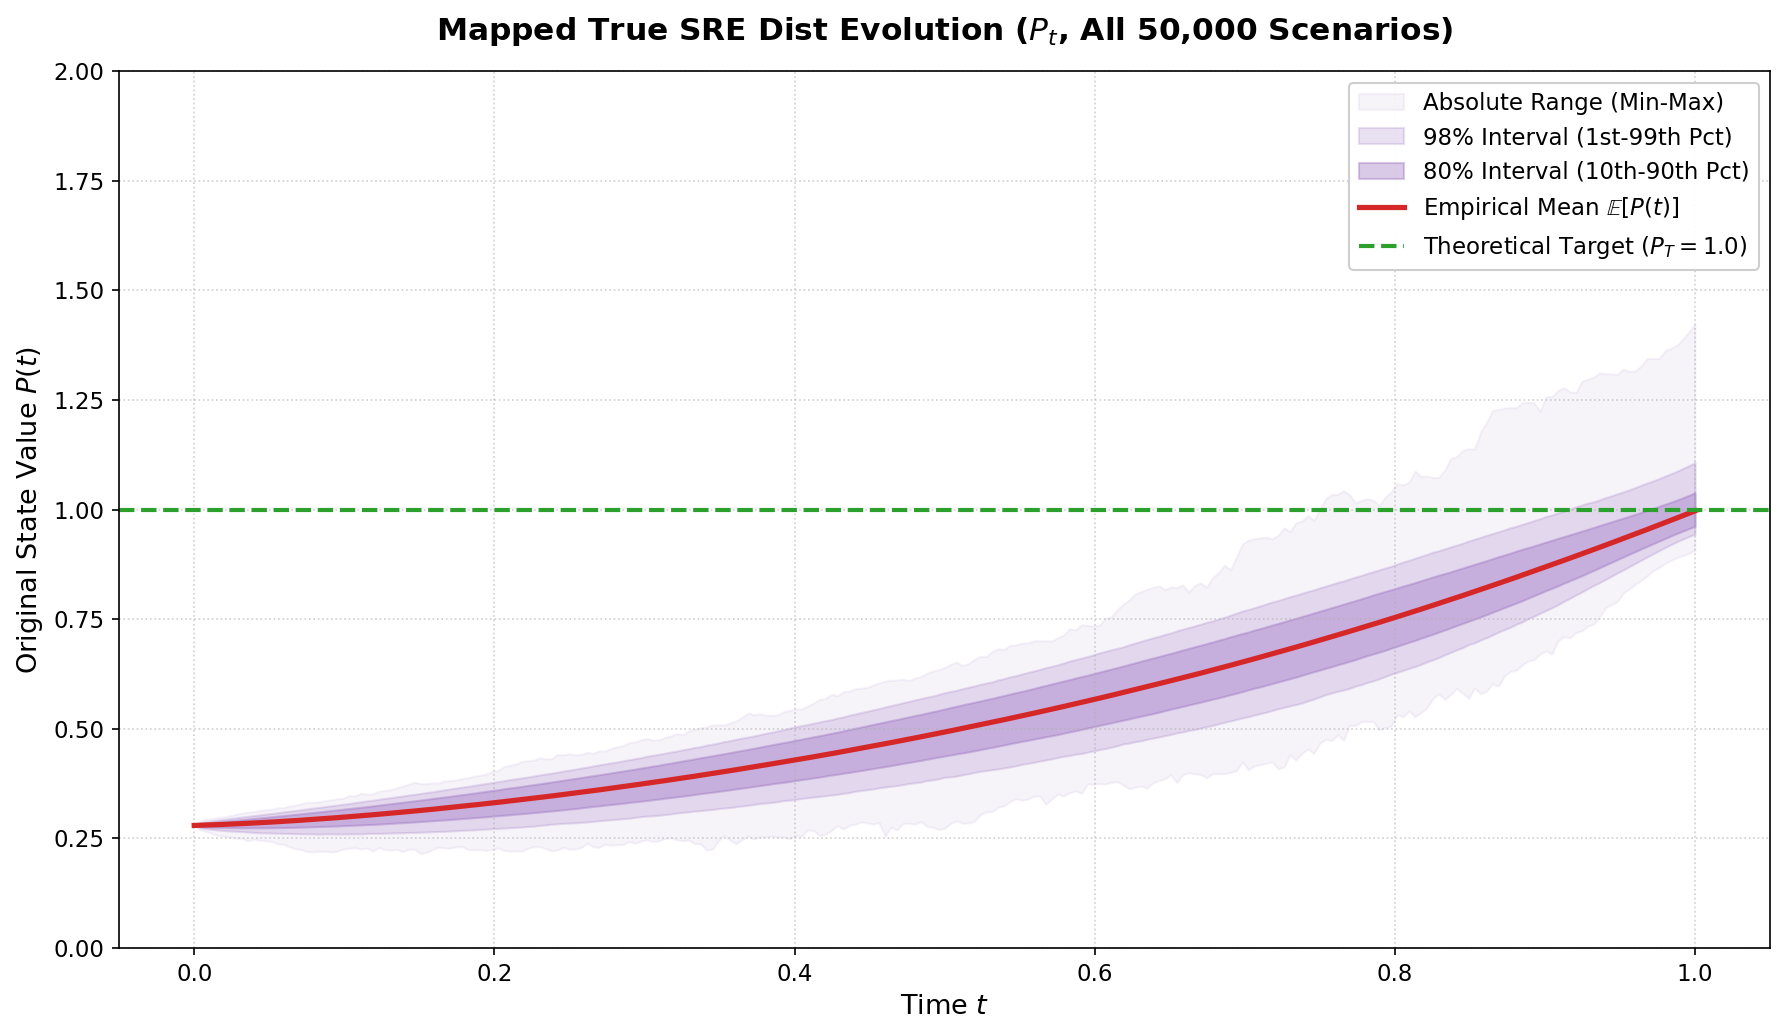

In [11]:


MODEL_PATH = 'value_net_final_complete_set2.pt'

true_sre_evaluator_orig = TrueSREVerifier_OriginalScale(
    solver=solver,
    device=DEVICE
)

TRUE_TEST_SCENARIOS = 50000
TRUE_TEST_SEED = 9999

V_true_test, dW_true_test = simulator.simulate_tensors(
    num_days=solver.N_steps,
    dt=solver.dt,
    num_scenarios=TRUE_TEST_SCENARIOS,
    seed=TRUE_TEST_SEED
)

P_history_all = true_sre_evaluator_orig.generate_true_sre_history(
    model_path=MODEL_PATH,
    V_test=V_true_test,
    dW_test=dW_true_test
)

mean_sre, std_sre, mse_sre = true_sre_evaluator_orig.evaluate_statistics(P_history=P_history_all)
true_sre_evaluator_orig.plot_true_sre_distribution(P_history=P_history_all)

del V_true_test, dW_true_test, P_history_all
torch.cuda.empty_cache()